# Supervisor Agent Architecture
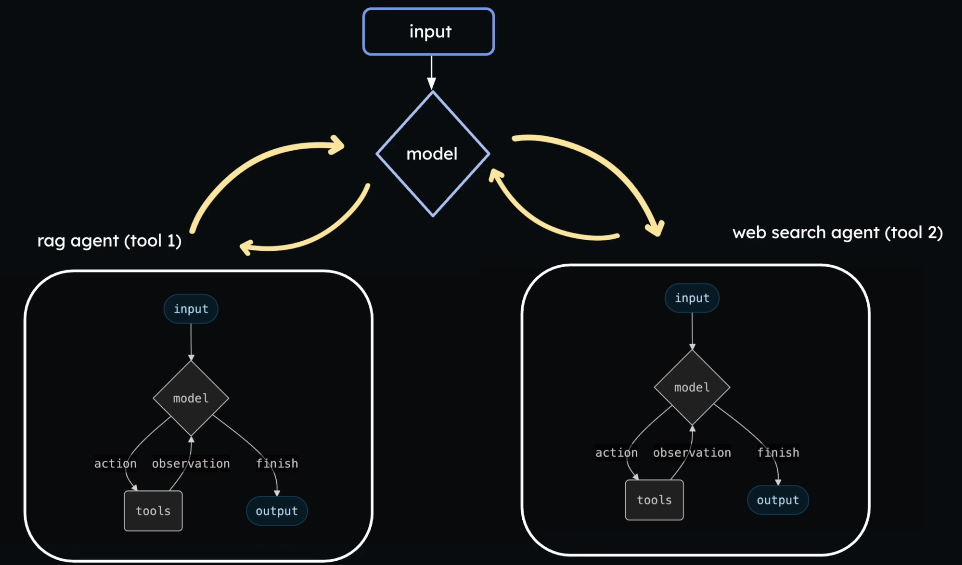

In [1]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()
cwd = Path().resolve()

if cwd.name == 'agents':
    project_root = cwd.parent.parent
elif cwd.name == "notebooks":
    project_root = cwd.parent
else:
    project_root = cwd

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


In [2]:
sys.path

['/Users/amruthakaruturi/gitrepos/Full-Stack-RAG-project/server',
 '/opt/homebrew/Cellar/python@3.11/3.11.14_1/Frameworks/Python.framework/Versions/3.11/lib/python311.zip',
 '/opt/homebrew/Cellar/python@3.11/3.11.14_1/Frameworks/Python.framework/Versions/3.11/lib/python3.11',
 '/opt/homebrew/Cellar/python@3.11/3.11.14_1/Frameworks/Python.framework/Versions/3.11/lib/python3.11/lib-dynload',
 '',
 '/Users/amruthakaruturi/Library/Caches/pypoetry/virtualenvs/six-figure-rag-api-5KEfUhx6-py3.11/lib/python3.11/site-packages']

In [6]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_tavily import TavilySearch
from src.rag.retrieval.index import retrieve_context
from src.rag.retrieval.utils import prepare_prompt_and_invoke_llm
from src.config.index import appConfig
import json
from langgraph.graph import MessagesState
from typing import Any, List, Dict
from typing_extensions import Annotated
from langgraph.types import Command
from langchain_core.tools.base import InjectedToolCallId
from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableConfig
from datetime import datetime

In [7]:
os.getenv("TAVILY_API_KEY")

'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'

In [8]:
class CustomAgentState(MessagesState):
    """Extended agent state with citation tracking."""
    citations: Annotated[List[Dict[str, Any]],lambda x, y: x + y] = []

In [9]:
# RAG Agent
# InjectedToolCallId This annotation is used to mark a tool parameter that should receive the tool call ID at runtime.

def create_rag_tool(project_id:str):
    """
    Create a RAG search tool bound to a specific project.
    
    This factory function creates a tool that is bound to a specific project_id,
    allowing the agent to search through that project's documents.
    
    Args:
        project_id: The UUID of the project whose documents should be searchable
        
    Returns:
        A LangChain tool configured for RAG search on the specified project
        
    Example:
        >>> rag_tool = create_rag_tool("123e4567-e89b-12d3-a456-426614174000")
    """
    @tool
    def rag_search(
        query: str,
        tool_call_id: Annotated[str, InjectedToolCallId],
    ) -> Command:
        """
        Search through project documents using RAG (Retrieval-Augmented Generation).
        This tool retrieves relevant context from the current project's documents based on the query.
        
        Args:
            query: The search query or question to find relevant information
            tool_call_id: Injected tool call ID for message tracking
            
        Returns:
            A Command object with updated messages and citations
        """
        try: 
            texts, images, tables, citations = retrieve_context(project_id, query)
            if not texts:
                return Command[tuple[()]](
                    update={
                        "messages": [
                            ToolMessage(
                                "No relevant informatin found in the project documents for this query",
                                tool_call_id = tool_call_id
                            )
                        ]
                    }
                )
            response = prepare_prompt_and_invoke_llm(
                user_query = query,
                texts = texts,
                images = images,
                tables = tables
            )
            return Command(
                update={
                    # update message history
                    "messages":[
                        ToolMessage(
                            content = response,
                            tool_call_id = tool_call_id
                        )
                    ],
                    # update citations in state - these accumulate
                    "citations": citations
                }
            )
                
        except Exception as e:
            return Command(
                update={
                    "messages": [
                        ToolMessage(
                            f"Error retrieving information: {str(e)}",
                            tool_call_id=tool_call_id
                        )
                    ]
                }
            )
        
    return rag_search


In [10]:
def create_rag_agent(project_id:str, model:str="gpt-4o"):
    """Create an agent with RAG tool for a specific project"""

    tools = [create_rag_tool(project_id)]
    system_prompt = """
    You are a helpful AI assistant with access to a RAG (Retrieval-Augmented Generation) tool that searches project-specific documents.

    For every user question:

    1. Do not assume any question is purely conceptual or general.  
    2. Use the `rag_search` tool immediately with a clear and relevant query derived from the user's question. 
    3. Carefully review the retrieved documents and base your entire answer on the RAG results.  
    4. If the retrieved information fully answers the user's question, respond clearly and completely using that information.  
    5. If the retrieved information is insufficient or incomplete, explicitly state that and provide helpful suggestions or guidance based on what you found.  
    6. Always present answers in a clear, well-structured, and conversational manner.

    **Make sure to call the rag_search tool correctly**
    **Never answer without first querying the RAG tool. This ensures every response is grounded in project-specific context and documentation.**
    """
    agent = create_agent(
        model = model,
        tools = tools,
        system_prompt = system_prompt,
        state_schema = CustomAgentState
    )
    return agent

In [21]:
# Web Search AGENT

def create_web_search_agent(model:str="gpt-4o", use_tavily:bool = True):
    """Create an agent with web searcg capabilities"""

    if use_tavily and os.getenv("TAVILY_API_KEY"):
        search_tool = TavilySearch(max_results=5, search_depth="advanced")
    else:
        search_tool = DuckDuckGoSearchRun()

    tools = [search_tool]

    current_date = datetime.now().strftime("%B %d, %Y")

    system_prompt = f"""You are a specialized web search assistant.
    Your job is to search the internet for current information and provide accurate, up-to-date answers.

    **Current Date: {current_date}**

    For every query you receive:
    1. **Reformulate vague queries into specific search terms** before searching
    2. Use the web search tool with clear, specific queries
    3. Synthesize information from multiple search results when possible
    4. Provide clear, factual answers with context
    5. Indicate the recency and reliability of information when relevant

    **Query Reformulation Examples:**
    - "What's trending on social media today?" → Try: "Twitter trending topics today" OR "viral news today"
    - "Today's top headlines" → Try: "breaking news today" OR "top news stories {current_date}"
    - "What's happening in tech?" → Try: "latest tech news today" OR "technology headlines today"
    - Add date context when relevant (e.g., "news {current_date}")

    **If initial search returns insufficient or irrelevant results:**
    1. Rephrase the query with more specific terms (e.g., add location, date, or focus area)
    2. Try searching with alternative keywords or synonyms
    3. Make 2-3 search attempts with different query formulations if needed
    4. If still unsuccessful, clearly state what you found vs. what was requested

    Focus on current events, general knowledge, and information not available in internal documents.
    Never fabricate information - only use what's found in search results."""
    agent = create_agent(
        model = model,
        tools = tools,
        system_prompt = system_prompt,
        state_schema = CustomAgentState
    )
    return agent

In [22]:
def create_supervisor_tools(project_id:str, model: str="gpt-4o"):
    """Create supervisor tools that wrap the specialized agents"""

    rag_agent = create_rag_agent(project_id=project_id, model=model)
    web_agent = create_web_search_agent(model=model)

    @tool
    def rag_search(
        query:str,
        tool_call_id: Annotated[str, InjectedToolCallId]
    ) -> Command:
        """Search internal project documents using RAG.
        
        Use this when the user asks about:
        - Project-specific information
        - Internal documentation
        - Previously uploaded files and documents
        - Company/project-specific data
        - Technical specifications from project files
        
        Args:
            query: Natural language query about project documents
            tool_call_id: Injected tool call ID for message tracking
            
        Returns:
            Command with relevant information from project documents and citations
        """
        result = rag_agent.invoke({
            "messages":[{"role":"user", "content": query}]
        })
        final_message = result["messages"][-1]
        content = final_message.content if hasattr(final_message, 'content') else str(final_message)
        citations = result.get("citations",[])
        return Command(
            update={
                "messages":[ToolMessage(content=content,tool_call_id=tool_call_id)],
                "citations": citations
            }
        )

    @tool
    def search_web(query: str) -> str:
        """Search the internet for current information.
        
        Use this when the user asks about:
        - Current events or recent news
        - General knowledge not in project documents
        - External information or public data
        - Market trends or industry news
        - Any information that requires up-to-date web sources
        
        Args:
            query: Natural language query for web search
            
        Returns:
            Relevant information from web search results
        """

        result = web_agent.invoke({
            "messages": [{"role": "user", "content": query}]
        })
        final_message = result["messages"][-1]
        content = final_message.content if hasattr(final_message, 'content') else str(final_message)
        return content

    return[rag_search, search_web]


In [23]:
def create_supervisor_agent(project_id:str, model:str="gpt-4o"):
    """Create a supervisor agent with the specified configuration"""

    tools = create_supervisor_tools(project_id=project_id, model=model)
    current_date = datetime.now().strftime("%B %d, %Y")

    system_prompt = f"""You are an intelligent supervisor assistant that coordinates between two specialized agents:

    **Current Date: {current_date}**

    ### Available Agents

    1. **Project Documents Agent** (rag_search):
    - Searches internal project documents using RAG
    - Use for project-specific queries, internal documentation, uploaded files

    2. **Web Search Agent** (search_web):
    - Searches the internet for current information
    - Use for current events, general knowledge, external information
    - ONLY use this tool if asked by the user or mentioned in the question

    ### Core Responsibilities

    - Analyze user queries and determine which agent(s) to use
    - Route queries to the appropriate agent(s) — you MUST NOT answer substantive questions directly
    - For complex queries, coordinate multiple agents in sequence
    - Synthesize results from multiple agents into coherent answers
    - Prioritize project documents for project-specific questions
    - Use web search ONLY if asked by the user or mentioned in the question
    - Use the chat history to understand the context and references in the current question

    ### Query Routing Rules

    **ALWAYS use tools for:**
    - Any question requiring factual information
    - Project-specific queries
    - Technical questions
    - Current events or news
    - General knowledge questions
    - Analysis or research requests

    **Direct response permitted ONLY for:**
    - Simple greetings (hi, hello, how are you)
    - Acknowledgments (thanks, ok, got it)
    - Basic clarification requests about your capabilities
    - Farewell messages (goodbye, bye)

    **ALWAYS use the RAG tool for the questions**
    **Return as much information that is given from the RAG tool as possible to the user**

    For all other queries, you MUST route to the appropriate agent(s) and synthesize their responses. Your role is coordination and synthesis, not direct knowledge provision.
    """

    agent = create_agent(
        model=model,
        tools=tools,
        system_prompt=system_prompt,
        state_schema=CustomAgentState
    )
    return agent

In [24]:
supervisor = create_supervisor_agent(project_id = "3ec5f8f3-0719-4bb3-863a-259ed3bcef3a", model="gpt-4o")

In [25]:
inputs = {"messages":[{"role": "user", "content": "What does this document say about latest rockets developments at spaceX, and search web for latest information on upcoming launches?"}]}

for chunk in supervisor.stream(inputs, stream_mode="updates"):
    for step, data in chunk.items():
        print(f"step: {step}")
        print(f"content: {data['messages'][-1].content_blocks}")

step: model
content: [{'type': 'tool_call', 'name': 'rag_search', 'args': {'query': 'latest rockets developments at SpaceX'}, 'id': 'call_1fPy75ZO1LSeWIyqguRmPzJ2'}, {'type': 'tool_call', 'name': 'search_web', 'args': {'query': 'upcoming SpaceX launches'}, 'id': 'call_ERH4veuZCsoIdZEjZj5Db1em'}]
Vector search resulted in: 10 chunks
context build results = texts:5, images:0, tables:0, citations:5

📦 CONTEXT VALIDATION

📝 TEXTS: 5 chunks

CHUNK [1] - 2430 characters
Rocket engines Since the founding of SpaceX in 2002, the company has developed several rocket engines – Merlin, Kestrel, and Raptor – for use in launch vehicles,[167][168] Draco for the reaction control system of the Dragon series of spacecraft,[169] and SuperDraco for abort capability in Crew Dragon.[170]

Merlin is a family of rocket engines that uses liquid oxygen (LOX) and RP-1 propellants. Merlin was first used to power the Falcon 1's first stage and is now used on both stages of the Falcon 9 and Falcon Heavy Merlin 1D e